# IMPORTS

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
import soundfile as sf
from PIL import Image
from pydub import AudioSegment
from pydub.utils import which
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# DATASET

## CREMA-D

### Load CREMA-D

In [12]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset_df = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset_df.shape[0])

7442


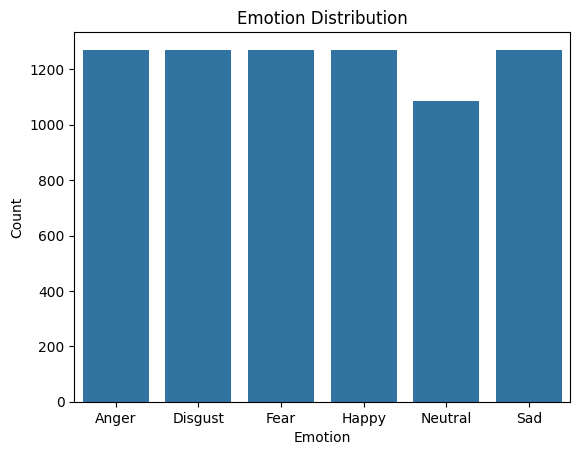

In [13]:
sns.countplot(x="emotion", data=dataset_df)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [4]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)

os.makedirs("CSVs", exist_ok=True)

In [ ]:
create_csv(dataset_df, "CSVs\\dataset.csv")


### Remove silence

In [15]:
AudioSegment.converter = which("ffmpeg")

location = "dataset_silenced\\"
os.makedirs(location, exist_ok=True)


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

# Process each audio file, remove leading and trailing silence, and save the new audio files
silence_progress_bar = tqdm(dataset_df.iterrows(), total=dataset_df.shape[0], desc="Removing silence from audio files")
for _, row in silence_progress_bar:
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Audio too short: {row['path']}, saved original audio.")

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

dataset_silenced = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

Removing silence from audio files:  86%|████████▌ | 6414/7442 [00:05<00:00, 1210.26it/s]

Audio too short: dataset\CREMA-D\AudioWAV\1076_MTI_SAD_XX.wav, saved original audio.


Removing silence from audio files: 100%|██████████| 7442/7442 [00:06<00:00, 1215.04it/s]


### Split dataset

In [16]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_df, groups=dataset_df["speaker"]))

gss = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(
    gss.split(
        dataset_df.loc[temp_idx], groups=dataset_df.loc[temp_idx]["speaker"]
    )
)

train_df = dataset_df.iloc[train_idx].reset_index(drop=True)
val_df = dataset_df.iloc[temp_idx].iloc[val_idx].reset_index(drop=True)
test_df = dataset_df.iloc[temp_idx].iloc[test_idx].reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

Train set: 5890 samples
Validation set: 732 samples
Test set: 820 samples


### Data augmentation

In [ ]:
import random

dataset_silenced = pd.read_csv("CSVs\\dataset_silenced.csv")
location = "dataset_augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

# Process each audio file, apply random augmentation, and save the new audio files
data_augmentation_progress_bar = tqdm(
    dataset_silenced.iterrows(),
    total=dataset_silenced.shape[0],
    desc="Augmenting audio files",
)

for _, row in data_augmentation_progress_bar:
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

train_df_augmented = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(train_df_augmented, "CSVs\\train_augmented.csv")

Augmenting audio files:   0%|          | 0/7442 [00:00<?, ?it/s]

Augmenting audio files: 100%|██████████| 7442/7442 [02:54<00:00, 42.73it/s] 


# CONVERT TO MEL SPECTROGRAM

## Config

In [5]:
location = "features\\"
csv_dir = "CSVs\\"
train_df = pd.read_csv(os.path.join(csv_dir, "train_augmented.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(csv_dir, "test.csv"))

MIN_SAMPLES = 2048
TARGET_DURATION = 3.0  # seconds
IMG_SIZE = 224

# Mel params 
# Đây là số lượng dải Mel sẽ được sử dụng để tạo ra spectrogram. 
# Số lượng này ảnh hưởng đến độ phân giải của spectrogram và 
# khả năng mô hình học được các đặc trưng quan trọng từ dữ liệu âm thanh.
N_MELS = 128

# Đây là kích thước của cửa sổ FFT được sử dụng để tính toán spectrogram.
# Kích thước này ảnh hưởng đến độ phân giải tần số của spectrogram và
# khả năng mô hình học được các đặc trưng tần số quan trọng từ dữ liệu âm thanh.
N_FFT = 1024  

# Đây là khoảng cách giữa các cửa sổ FFT liên tiếp khi tính toán spectrogram.
# Khoảng cách này ảnh hưởng đến độ phân giải thời gian của spectrogram và
# khả năng mô hình học được các đặc trưng thời gian quan trọng từ dữ liệu âm thanh.
HOP_LENGTH = 256  

## Run

In [4]:
location = "features/images/"
os.makedirs(location, exist_ok=True)

IMG_SIZE = 224


def graph_spectrogram(gs_audio: str, gs_file_name: str) -> None:
    y, sr = librosa.load(gs_audio, sr=None)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  # range: [-80, 0] dB

    fig, ax = plt.subplots(1)
    fig.set_size_inches(IMG_SIZE / 100, IMG_SIZE / 100)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.axis("off")

    librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_LENGTH, ax=ax, cmap="viridis"
    )

    fig.savefig(gs_file_name, dpi=100)
    plt.close(fig)


def prepare_images(pi_df, pi_name: str) -> None:
    data = []
    labels = []

    prepare_images_progress_bar = tqdm(
        pi_df.iterrows(), total=len(pi_df), desc=f"Processing {pi_name}"
    )
    for idx, row in prepare_images_progress_bar:
        file_name = f"{location}{pi_name}_{idx}.png"
        if not os.path.exists(file_name):
            graph_spectrogram(row["path"], file_name)

        image = cv2.imread(file_name, cv2.IMREAD_COLOR)
        if image is None:
            print(f"Error loading image: {row['path']}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # (H, W, 3) uint8
        data.append(image)
        labels.append(row["emotion"])

    data = np.array(data, dtype=np.uint8)
    labels = np.array(labels)

    data_name = f"{pi_name}_images_data.npy"
    labels_name = f"{pi_name}_images_labels.npy"
    np.save(f"features/{data_name}", data)
    np.save(f"features/{labels_name}", labels)
    print(f"Saved {len(data)} images and labels for {pi_name}.")


data_path_Train = pd.read_csv("CSVs/train_augmented.csv")
data_path_Val = pd.read_csv("CSVs/val.csv")
data_path_Test = pd.read_csv("CSVs/test.csv")

prepare_images(data_path_Train, "train")
prepare_images(data_path_Val, "val")
prepare_images(data_path_Test, "test")

Processing train: 100%|██████████| 14884/14884 [02:59<00:00, 82.82it/s] 


Saved 14884 images and labels for train.


Processing val: 100%|██████████| 732/732 [00:58<00:00, 12.62it/s]


Saved 732 images and labels for val.


Processing test: 100%|██████████| 820/820 [01:12<00:00, 11.24it/s]


Saved 820 images and labels for test.


# DATA LOADER

## Unload processed spetrogram images

In [6]:
x_trainI = np.load('features\\train_images_data.npy')
x_validationI = np.load('features\\val_images_data.npy')
x_testI = np.load('features\\test_images_data.npy')

Labels_train_I = np.load('features\\train_images_labels.npy')
Labels_val_I = np.load('features\\val_images_labels.npy')
Labels_test_I = np.load('features\\test_images_labels.npy')

# One-hot encoding

encoder = OneHotEncoder(sparse_output=False)
y_trainI = encoder.fit_transform(np.array(Labels_train_I).reshape(-1, 1))
y_validationI = encoder.transform(np.array(Labels_val_I).reshape(-1, 1))
y_testI = encoder.transform(np.array(Labels_test_I).reshape(-1, 1))

print(x_trainI.shape)
print(x_validationI.shape)
print(x_testI.shape)
print(y_trainI.shape)
print(y_validationI.shape)
print(y_testI.shape)

(14884, 224, 224, 3)
(732, 224, 224, 3)
(820, 224, 224, 3)
(14884, 6)
(732, 6)
(820, 6)


## Data loader

In [7]:
# Create a mapping from emotion labels to integers
dataset_df = pd.read_csv("CSVs/dataset.csv")
emotion_list = sorted(dataset_df["emotion"].unique())
emotion_to_int = {emotion: i for i, emotion in enumerate(emotion_list)}
int_to_emotion = {i: emotion for emotion, i in emotion_to_int.items()}


class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # uint8 numpy array (N, H, W, 3)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # uint8
        label = self.labels[idx]

        image = Image.fromarray(image)  # PIL từ uint8 trực tiếp

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(np.argmax(label)).long()
        return image, label

print(f'Emotion {len(emotion_list)}: {emotion_list}')

Emotion 6: ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']


In [8]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),                              # uint8 → float [0,1]
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD), # ImageNet stats
    ]),
    "val": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "test": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

# Create Datasets
train_dataset = EmotionDataset(x_trainI, y_trainI, transform=data_transforms["train"])
val_dataset = EmotionDataset(x_validationI, y_validationI, transform=data_transforms["val"])
test_dataset = EmotionDataset(x_testI, y_testI, transform=data_transforms["test"])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloaders = {"train": train_loader, "val": val_loader, "test": test_loader}
dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset),
}

print(f"Train loader size: {len(train_loader)}")
print(f"Validation loader size: {len(val_loader)}")
print(f"Test loader size: {len(test_loader)}")


Train loader size: 466
Validation loader size: 23
Test loader size: 26


# MODEL

## ResNet18

In [23]:
class build_Resnet(nn.Module):
    def __init__(self, num_classes):
        super(build_Resnet, self).__init__()
 
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
 
        for param in self.model.parameters():
            param.requires_grad = False
 
        for layer in [self.model.layer4]:
            for param in layer.parameters():
                param.requires_grad = True
 
        self.model.fc = nn.Sequential(  # type: ignore
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, x):
        return self.model(x)
 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ResNet = build_Resnet(num_classes=6).to(device)
 
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
 
optimizer = optim.AdamW([
    {"params": ResNet.model.layer4.parameters(), "lr": 1e-5},
    {"params": ResNet.model.fc.parameters(),     "lr": 5e-5},
], weight_decay=5e-4)
 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
 
print(f"Using device: {device}")
 
print(ResNet)

Using device: cuda:0
build_Resnet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1

## DenseNet121

In [24]:
class build_DenseNet(nn.Module):
    def __init__(self, num_classes):
        super(build_DenseNet, self).__init__()

        self.model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.features.denseblock4.parameters():  # type: ignore
            param.requires_grad = True

        for param in self.model.features.norm5.parameters():  # type: ignore
            param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(self.model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DenseNet = build_DenseNet(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    [
        {"params": DenseNet.model.features.denseblock4.parameters(), "lr": 1e-5},  # type: ignore
        {"params": DenseNet.model.classifier.parameters(), "lr": 5e-5},  # type: ignore
    ],
    weight_decay=5e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"Using device: {device}")
print(DenseNet)

Using device: cuda:0
build_DenseNet(
  (model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(9

## VGG16

In [25]:
class build_VGG(nn.Module):
    def __init__(self, num_classes):
        super(build_VGG, self).__init__()

        self.model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for layer in self.model.features[24:]:  # type: ignore
            for param in layer.parameters():
                param.requires_grad = True

        self.model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.6),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.6),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
VGG = build_VGG(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    [
        {"params": VGG.model.features[24:].parameters(), "lr": 1e-5},  # type: ignore
        {"params": VGG.model.classifier.parameters(), "lr": 5e-5},  # type: ignore
    ],
    weight_decay=5e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)


print(f"Using device: {device}")
print(VGG)

Using device: cuda:0
build_VGG(
  (model): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inp

## EfficientNet-B0

In [26]:
class build_EfficientNet(nn.Module):
    def __init__(self, num_classes):
        super(build_EfficientNet, self).__init__()

        self.model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        for param in self.model.parameters():
            param.requires_grad = False

        for layer in self.model.features[6:]:  # type: ignore
            for param in layer.parameters():
                param.requires_grad = True

        in_features = self.model.classifier[1].in_features  # type: ignore
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 256),  # type: ignore
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

EffNet = build_EfficientNet(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    [
        {"params": EffNet.model.features[6:].parameters(), "lr": 1e-5},  # type: ignore
        {"params": EffNet.model.classifier.parameters(), "lr": 5e-5},  # type: ignore
    ],
    weight_decay=5e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"Using device: {device}")
print(EffNet)

Using device: cuda:0
build_EfficientNet(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=Tr

# TRAIN / VALIDATE / TEST

## Train & Validate

In [15]:
EPOCHS = 100
PATIENCE = 15

best_val_loss = float("inf")
best_epoch = 0
counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_recall": [],
    "train_precision": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_recall": [],
    "val_precision": [],
}

MODEL = EffNet


for epoch in range(EPOCHS):
    # ==========================
    # TRAIN
    # ==========================
    MODEL.train()

    train_labels_all = []
    train_preds_all = []
    running_loss = 0
    train_total = 0

    tqdm_loader = tqdm(
        train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Training", leave=False
    )
    for images, labels in tqdm_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = MODEL(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        train_total += batch_size

        preds = torch.argmax(outputs, dim=1)
        train_labels_all.extend(labels.cpu().numpy())
        train_preds_all.extend(preds.cpu().numpy())

    train_loss = running_loss / train_total
    train_acc = accuracy_score(train_labels_all, train_preds_all)
    train_f1 = f1_score(train_labels_all, train_preds_all, average="weighted")
    train_recall = recall_score(
        train_labels_all, train_preds_all, average="weighted", zero_division=0
    )
    train_precision = precision_score(
        train_labels_all, train_preds_all, average="weighted", zero_division=0
    )

    # ==========================
    # VALIDATION
    # ==========================
    MODEL.eval()
    val_labels_all = []
    val_preds_all = []
    val_running_loss = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(
            val_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Validation", leave=False
        ):
            images = images.to(device)
            labels = labels.to(device)

            outputs = MODEL(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            val_running_loss += loss.item() * batch_size
            val_total += batch_size

            preds = torch.argmax(outputs, dim=1)
            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(preds.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_acc = accuracy_score(val_labels_all, val_preds_all)
    val_f1 = f1_score(val_labels_all, val_preds_all, average="weighted")
    val_recall = recall_score(
        val_labels_all, val_preds_all, average="weighted", zero_division=0
    )
    val_precision = precision_score(
        val_labels_all, val_preds_all, average="weighted", zero_division=0
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_recall"].append(train_recall)
    history["train_precision"].append(train_precision)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_recall"].append(val_recall)
    history["val_precision"].append(val_precision)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(
        f"Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f} | Recall: {train_recall:.4f} | Precision: {train_precision:.4f}"
    )
    print(
        f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | Recall: {val_recall:.4f} | Precision: {val_precision:.4f}"
    )
    # In lr của từng group để theo dõi
    for i, pg in enumerate(optimizer.param_groups):
        print(f"LR group {i}: {pg['lr']:.2e}")

    # ==========================
    # EARLY STOPPING & SAVE BEST MODEL
    # ==========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        counter = 0
        torch.save(MODEL.state_dict(), f"{MODEL._get_name()}.pth")
        print("--> New Best Model Saved!")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# ==========================
# RESTORE BEST WEIGHTS
# ==========================
MODEL.load_state_dict(
    torch.load(f"{MODEL._get_name()}.pth", map_location=device, weights_only=True)
)
print(f"Best epoch: {best_epoch}")

Epoch 1/100
Train | Loss: 1.6467 | Acc: 0.3346 | F1: 0.3120 | Recall: 0.3346 | Precision: 0.3249
Val   | Loss: 1.4684 | Acc: 0.4549 | F1: 0.4032 | Recall: 0.4549 | Precision: 0.4902
LR group 0: 1.00e-05
LR group 1: 5.00e-05
--> New Best Model Saved!


KeyboardInterrupt: 

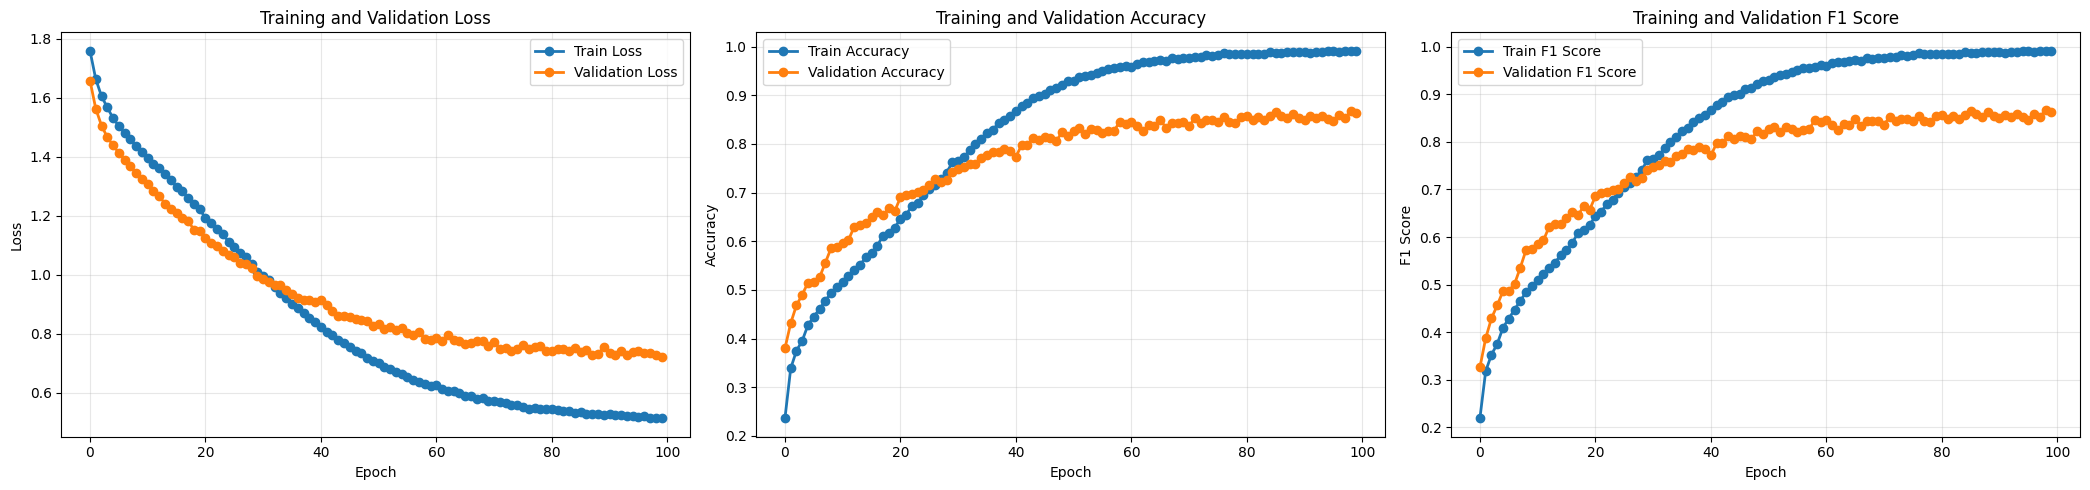

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train F1 Score', marker='o', linewidth=2)
axes[2].plot(history['val_f1'], label='Validation F1 Score', marker='o', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Training and Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test


Evaluating on test set...
Classification Report (Test):
              precision    recall  f1-score   support

       Anger       0.83      0.90      0.86       140
     Disgust       0.80      0.76      0.78       140
        Fear       0.81      0.83      0.82       140
       Happy       0.83      0.84      0.83       140
     Neutral       0.90      0.88      0.89       120
         Sad       0.83      0.79      0.81       140

    accuracy                           0.83       820
   macro avg       0.83      0.83      0.83       820
weighted avg       0.83      0.83      0.83       820



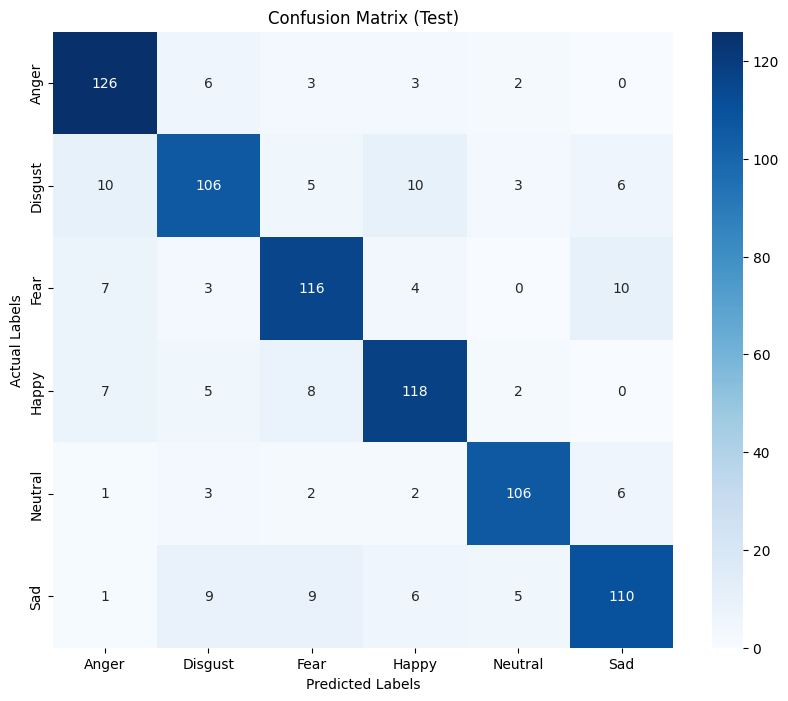

In [16]:
# Helper to evaluate model on a dataloader
def evaluate_model(model, loader, device=device):
	model.eval()
	true_labels = []
	predicted_labels = []
	with torch.no_grad():
		for images, labels in loader:
			images = images.to(device)
			labels = labels.to(device)
			outputs = model(images)
			preds = torch.argmax(outputs, dim=1)
			predicted_labels.extend(preds.cpu().numpy().tolist())
			true_labels.extend(labels.cpu().numpy().tolist())
	return true_labels, predicted_labels

# Evaluate on the test set
print("\nEvaluating on test set...")
true_labels, predicted_labels = evaluate_model(MODEL, test_loader)

# Classification Report
print("Classification Report (Test):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()